<a href="https://colab.research.google.com/github/TejasDharmale/complex-adaptive-systems/blob/main/CAS_assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - Stochastic Processes

Name: Tejas Dharmale

Student: s1190137

In [9]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr

# ADD YOUR RK4 SOLVER FROM LAST WEEK'S ASSIGNMENT

In [10]:
# General RK4 function
def get_rk4(f, dt):
    def rk4_scan_fn(carry, t):
        k1 = f(carry, t)
        k2 = f(carry + dt*k1/2, t + dt/2)
        k3 = f(carry + dt*k2/2, t + dt/2)
        k4 = f(carry + dt*k3, t + dt)

        next_state = carry + dt*(k1 + 2*k2 + 2*k3 + k4)/6

        return next_state, next_state

    return rk4_scan_fn

# Exercise 1: Lotka-Volterra system

The Lotka-Volterra model is a non-linear system to describe periodic dynamics of prey ($x$) and predator ($y$) populations. This makes the system relevant for biological and ecological systems, as this periodic behavior is often observed in real life. The equations are defined by:

$$\dot{x}=\alpha x - \beta x y$$

$$\dot{y}=\delta xy - \gamma y$$

In the following exercise, you can use the following values for the parameters: $\alpha=1.1, \beta=0.4, \delta=0.1, \gamma=0.4$.

## Exercise 1.1: Stability analysis (3 points)

The Lotka-Volterra model has a fixed point at $(\gamma/\delta, \alpha/\beta)$. Linearize the system at the fixed point (slide 26) and perform a stability analysis to characterize the behaviour of the system near the fixed point. You can make use of the following function to determine the eignevalues: `numpy.linalg.eig(A)`

## Solution 1.1

YOUR ANSWER HERE

In [11]:
alpha, beta, delta, gamma = 1.1, 0.4, 0.1, 0.4
# YOUR STABILITY ANALYSIS
x_star = gamma / delta
y_star = alpha / beta
A = jnp.array([[alpha - beta * y_star,   -beta * x_star ],
               [delta * y_star,           delta * x_star - gamma]])
print(A)
eigvals, eigvecs = jnp.linalg.eig(A)
print(eigvals)

[[ 0.    -1.6  ]
 [ 0.275  0.   ]]
[0.+0.663325j 0.-0.663325j]


In [12]:
# STABILITY ANALYSIS:
# Jacobian at the fixed point (x*, y*) = (gamma/delta, alpha/beta) = (4, 2.75):
# A = [[0, -1.6],
# [0.275, 0]]

# Eigenvalues: lambda = 0 + 0.663j and 0 - 0.663j (purely imaginary, lambda = +/- i*sqrt(beta*gamma*alpha/beta) = +/- i*sqrt(alpha*gamma))

# Real part: since the real part of the eigenvalues is zero for both eigenvalues, the perturbations around the
# fixed point do not grow (unstable) or decay (asymptotically stable).

# Imaginary part: non-zero imaginary part (omega = 0.663) indicates that the system is oscillating around the fixed point:
# prey and predator numbers are increasing and decreasing periodically.
# Period of small oscillations is T = 2*pi/omega = 2*pi/0.663 ≈ 9.47 time units.

# Type of fixed point: it is a center. Since near point (4, 2.75) trajectories of Lotka-Volterra system form closed loops around the fixed point,
# then it is neutrally (Lyapunov) stable but not asymptotically stable.

# Important remark: if the real part of an eigenvalue is zero, then the linearization can not completely define the stability of the nonlinear system
# because some small nonlinear terms may change the type of the fixed point (make it stable or unstable spiral). The numerical simulation verifies this prediction:
# trajectories of Lotka-Volterra model have closed periodic loops

## Exercise 1.2: Phase portrait (3 points)

Visualize the phase plane of the Lotka-Volterra dynamics. You can create a grid of $x$ and $y$ coordinates with `jnp.meshgrid`. For the visualization, you should use `plt.streamplot`. Note that this method does not accept JAX arrays, so convert them to `numpy` first.

Next, simulate a few trajectories with different initial conditions, and plot them in the same figure as periodic orbits. Make sure the simulations are long enough to cover on full orbit. Finally, show the two fixed points of the system as dots in the figure.

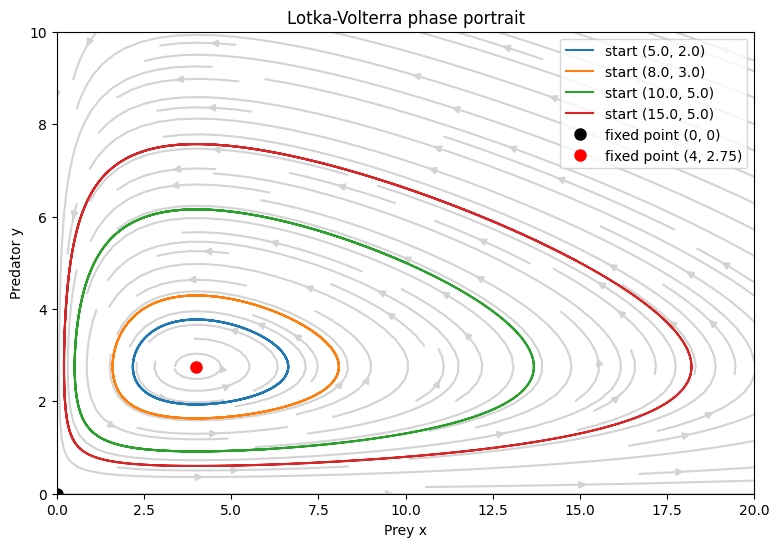

In [13]:
def lotka_volterra(X, t):
    """
    Lotka-Volterra model
    X: state vector [x, y] with prey x and predator y
    a: growth rate for prey
    b: death rate for prey due to pred-prey interaction
    d: growth rate for pred due to pred-prey interaction
    g: death rate for pred
    """
    x, y = X[0], X[1]
    dx = alpha * x - beta * x * y
    dy = delta * x * y - gamma * y
    return jnp.array([dx, dy])


xs = jnp.linspace(0, 20, 40)
ys = jnp.linspace(0, 10, 40)
X, Y = jnp.meshgrid(xs, ys)


dX, dY = lotka_volterra(jnp.array([X, Y]), 0.0)

plt.figure(figsize=(9, 6))


plt.streamplot(jax.device_get(X), jax.device_get(Y),
               jax.device_get(dX), jax.device_get(dY),
               color="lightgray", density=1.2)


dt = 0.01
t = jnp.arange(0, 30, dt)

for x0, y0 in [(5.0, 2.0), (8.0, 3.0), (10.0, 5.0), (15.0, 5.0)]:
    init_state = jnp.array([x0, y0])
    _, traj = jax.lax.scan(get_rk4(lotka_volterra, dt), init_state, t)
    plt.plot(traj[:, 0], traj[:, 1], label=f"start ({x0}, {y0})")


plt.plot(0, 0, "ko", markersize=8, label="fixed point (0, 0)")
plt.plot(x_star, y_star, "ro", markersize=8, label=f"fixed point ({x_star:.0f}, {y_star:.2f})")

plt.xlabel("Prey x")
plt.ylabel("Predator y")
plt.title("Lotka-Volterra phase portrait")
plt.xlim(0, 20)
plt.ylim(0, 10)
plt.legend(loc="upper right")
plt.show()

In [14]:
# OBSERVATIONS:
# All trajectories form closed orbits around the fixed point (4, 2.75), confirming the
# center found in the stability analysis: populations oscillate periodically and never
# spiral in or out. Orbits starting further from the fixed point are larger and less
# elliptical, since the nonlinear terms matter more far away. The fixed point (0, 0)
# is a saddle: with no predators the prey grows along the x-axis, and with no prey the
# predators die out along the y-axis.

# Exercise 2 - Lorentz attractor

The dynamics of the Lorenz attractor are given by:

$$\dot{x} = \sigma (y - x)$$
$$\dot{y} = \rho x - y - xz$$
$$\dot{z} = xy - \beta (z)$$

with $\sigma = 10$,
$\rho = 28$,
$\beta = 8/3$

## Exercise 2.1 (2 points)

Reconstruct the Lorenz attractor in figure 44 (dynamical systems theory), by integrating the system for an initial condition of choice with a sufficiently low step size. Make use of the RK4 solver from last week's assignment.

## Solution 2.1

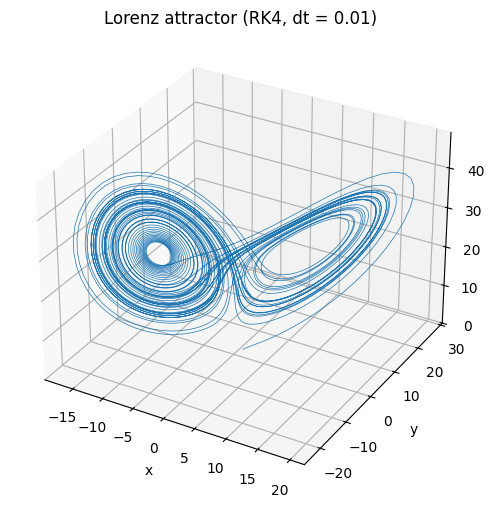

In [20]:
# lorenz system
def lorenz(x, sigma = 10.0, rho = 28.0, beta = 8.0 / 3.0):
    _x, _y, _z = x
    dx = sigma * (_y - _x)
    dy = rho * _x - _y - _x * _z
    dz = _x * _y - beta * _z
    return jnp.array([dx, dy, dz])

f_lorenz = lambda t, x, args: lorenz(x)

f = lambda state, t: f_lorenz(t, state, None)


dt = 0.01                          #
t = jnp.arange(0, 50, dt)
init_state = jnp.array([1.0, 1.0, 1.0])

# Integrate with RK4
_, traj = jax.lax.scan(get_rk4(f, dt), init_state, t)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], linewidth=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz attractor (RK4, dt = 0.01)")
plt.show()


In [19]:
# OBSERVATION:
# The trajectory circles one of two "wings" for a while, then switches to the other
# at irregular moments. It never repeats and never settles on a fixed point or a
# closed orbit: this is the strange attractor of the chaotic Lorenz system.

## Exercise 2.2 (2 points)

Simulate the trajectories for 100 initial conditions, all of which are minor (random) deviations from the initial condition you used in part a.  Visualize the solution trajectories with time on the x-axis, with a different plot for each variable of the attractor. What happens to the trajectories as time increases?  

## Solution 2.2

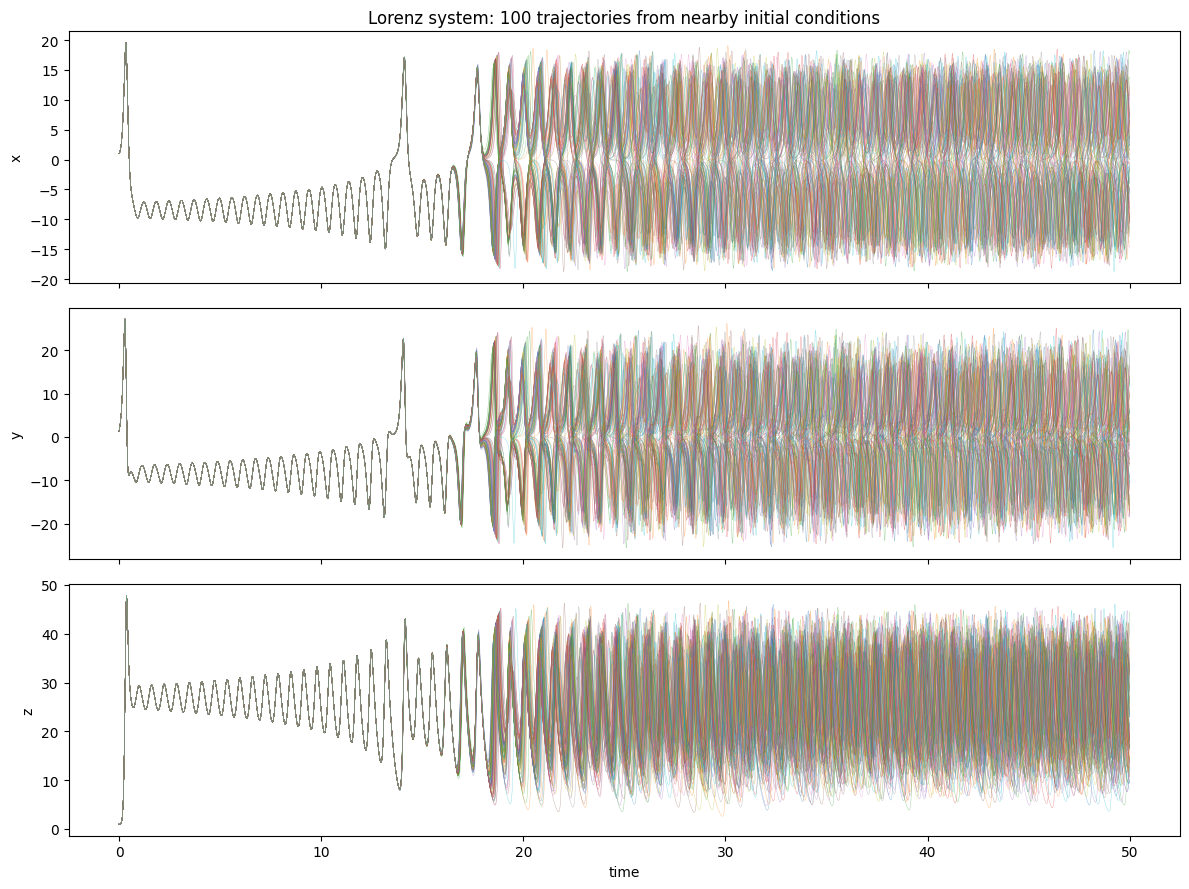

In [22]:
# 1. Create 100 initial conditions: tiny random deviations from init_state
key = jr.PRNGKey(0)
n_traj = 100
noise = 1e-3 * jr.normal(key, (n_traj, 3))
init_states = init_state + noise

# 2. Simulate one trajectory with RK4
def simulate(x0):
    _, traj = jax.lax.scan(get_rk4(f, dt), x0, t)
    return traj

# 3. Run all 100 simulations at once
trajs = jax.vmap(simulate)(init_states)


fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
names = ["x", "y", "z"]

for i, ax in enumerate(axes):
    ax.plot(t, trajs[:, :, i].T, linewidth=0.3, alpha=0.5)
    ax.set_ylabel(names[i])

axes[-1].set_xlabel("time")
axes[0].set_title("Lorenz system: 100 trajectories from nearby initial conditions")
plt.tight_layout()
plt.show()